<a href="https://colab.research.google.com/github/redsheep913/generative_ai/blob/main/%E7%94%9F%E6%88%90%E5%BC%8FAI_HW2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 1. 讀入套件

In [1]:
!pip install gradio

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 MB 10.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.1/322.1 kB 13.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.9/94.9 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 78.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.0/72.0 kB 5.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.3/62.3 kB 4.1 MB/s eta 0:00:00
  Attempting uninstall: markupsafe
    Found existing installation: MarkupSafe 3.0.2
    Uninstalling MarkupSafe-3.0.2:
      Successfully uninstalled MarkupSafe-3.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torch 2.5.1+cu124 requires nvidia-cublas-cu12==12.4.5.8; platform_system == "Linux" and platform_machine == "x86_64", but you have nvidia-cublas-cu12 12.5.3.2 which is incompatible.
to

In [2]:
%matplotlib inline

# 標準數據分析、畫圖套件
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# 神經網路方面
import tensorflow as tf
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD

# 互動設計用
from ipywidgets import interact_manual

# 神速打造 web app 的 Gradio
import gradio as gr

## 2. 讀入 MNIST 數據庫

In [3]:
# 用Keras讀入數據並且看看訓練資料跟測試資料的數量
(x_train, y_train), (x_test, y_test) = mnist.load_data() #(訓練輸入, 訓練輸出), (測試輸入, 測試輸出)
print("mnist資料讀入完成")
print(f'訓練資料總筆數為 {len(x_train)} 筆資料')
print(f'測試資料總筆數為 {len(x_test)} 筆資料')

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
mnist資料讀入完成
訓練資料總筆數為 60000 筆資料
測試資料總筆數為 10000 筆資料


In [4]:
x_train.shape

(60000, 28, 28)

### x_train.shape
- 60000: 表示訓練數據集中有 60,000 張圖片。這是模型在訓練過程中將學習的樣本總數。

- 28: 表示每張圖片的寬度，以像素為單位。

- 28: 表示每張圖片的高度，以像素為單位。

In [11]:
# 手寫辨識的數據 想留著看!
x_train[1122]



array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
         64, 185, 254, 254, 212,  25,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  12, 115,
        247, 254, 253, 253, 253, 208,  28,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  15, 181, 253,
        253, 254, 253, 253, 253, 253,  66,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,  89, 220, 253, 249,
        173,  40,  39, 161, 253, 253, 179,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0, 159, 240, 253, 253, 204,
          0,  32, 124, 248, 253, 253, 228,  42,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,  89, 240, 253, 253, 253, 144,
        187, 220, 253, 253, 253, 253, 199,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0, 214, 253, 253, 253, 253, 253,
        253, 254, 215, 157, 253, 253, 108,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0, 129, 253, 253, 253, 253, 252,
        226,  94,   5, 179, 253, 253,  66,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,  34, 212, 240, 240, 226, 101,
          0,   0,   0, 228, 253, 250,  63,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,  57, 241, 253, 186,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0, 171, 254, 254,  53,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,  52, 246, 253, 176,   3,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0, 170, 253, 253, 124,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   5,
        151, 254, 253, 223,  27,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  14,
        253, 254, 253,  54,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 113,
        253, 254, 230,  21,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  19, 220,
        253, 255,  76,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   

In [9]:
# 手寫辨識的數據 想留著看!
x_train[12134]


array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   1,  82, 209, 255, 138,   3,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,  36, 253, 253, 253, 253,  60,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,  93, 254, 253, 253, 253, 253, 135,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  17,  30,
         97, 250, 254, 253, 253, 253, 253, 229,  32,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,  18, 183, 226,
        247, 253, 254, 253, 140, 164, 253, 253, 134,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0, 108, 253, 225,
        247, 253, 254, 246,  69,  49, 253, 253, 168,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,  21, 214, 225,  47,
         96, 209, 250,  95,   0,  49, 253, 253, 237,  29,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,  61, 253, 168,   0,
          0,  17,  34,   0,   0,  49, 253, 253, 253,  36,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,  45, 236, 253, 168,   0,
          0,   0,   0,   0,   0,  49, 253, 253, 176,   4,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,  49, 253, 253, 168,   0,
          0,   0,   0,   0,   0,  49, 253, 253, 168,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0, 170, 254, 254, 106,   0,
          0,   0,   0,   0,   0, 113, 254, 254, 169,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,  21, 218, 253, 253,  48,   0,
          0,   0,   0,   0,  91, 218, 253, 253, 100,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,  37, 253, 253, 253,  48,   0,
          0,   0,   0,  33, 217, 253, 253, 208,  18,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0, 118, 253, 253, 204,  16,   0,
          0,   0,   9, 218, 253, 253, 253, 100,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0, 157, 253, 253, 233,  34,   0,
          0,  30, 128, 253, 253, 253, 181,  17,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0, 123, 253, 253, 253,  83,   0,
         67, 217, 254, 253, 253, 181,  17,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,  25, 225, 253, 253, 237, 206,
        249, 253, 254, 253, 183,  16,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0, 124, 253, 253, 253, 253,
        253, 253, 254, 186,  14,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,  28, 170, 253, 253, 253,
        253, 253, 139,  10,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   3, 104, 231, 253,
        201,  75,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   

## 3. 資料前處理


In [12]:
# 將訓練輸入的圖片(28*28)拉長成向量(長度784)，換句話說就是把資料拉平平的
x_train = x_train.reshape(60000, 784)/255
x_test = x_test.reshape(10000, 784)/255

# 將訓練輸出的數據(0~9)編碼成向量(長度10)，例如:9=>[0,0,0,0,0,0,0,0,0,1]
# 做one-hot encoding
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)

## 4. 構建自己的神經網路

In [15]:
# 跟做迴歸跟機器學習一樣，打開個函數學習機
# 標準一層一層傳遞的神經網路叫做 Sequential
# 打開一個空的neural network
model = Sequential()

# 輸入神經網路各層數的神經元數量
layer = [ 40, 50, 60, 70 ]
layer_num = len(layer)

# 輸入層
model.add(Dense(layer[0], input_dim=784, activation='relu'))

# 隱藏層
for i in layer[1:]:
    model.add(Dense(i, activation='relu'))

# 輸出層
model.add(Dense(10, activation='softmax'))

/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


# Output Layer 輸出層

### 使用 Dense(10, activation='softmax') 的原因
* `Dense(10)` 代表有10個神經元，對應數字0-9的10個類別
* 每個神經元輸出一個類別的預測分數

### Softmax 激活函數作用
* 將原始分數轉換為機率分布
* 所有10個輸出值相加為1 (100%)
* 確保每個類別的預測機率在0到1之間
* 最大的值對應模型認為最可能的數字

### 數學原理
* Softmax公式將任意實數向量轉換為機率分布：

$$
\text{softmax}(z_i) = \frac{e^{z_i}}{\sum_{j=1}^{10} e^{z_j}}
$$

* 例如，原始輸出 [2.0, 1.0, 0.1, ...] 轉換為機率 [0.65, 0.24, 0.01, ...]

### 與交叉熵的配合
* Softmax輸出的機率分布與交叉熵損失函數完美配合
* 交叉熵可以有效量化預測機率與真實標籤之間的差距
* 這種組合在訓練過程中提供穩定且有效的梯度



In [19]:
#可調整(loss = 損失函數, optimizer = 優化器, learning_rate = 學習率)
model.compile(
    loss='categorical_crossentropy',
    optimizer=SGD(learning_rate=0.01, momentum=0.9),
    metrics=['accuracy']
)

# Cross-entropy Loss 交叉熵損失函數

### 基本原理
* `categorical_crossentropy` 是多類別分類問題的標準損失函數
* 它測量預測概率分布與真實標籤分布之間的差異
* 當預測與真實標籤越接近時，損失值越小
* 非常適合像手寫數字辨識這樣的多類別問題

### 數學表達
* 假設有K個類別(手寫數字0-9共10個類別)
* y是真實標籤的one-hot編碼向量
* p是模型預測的概率向量

$$
L = -\sum_{i=1}^{K} y_i \log(p_i)
$$

### 優勢說明
* 相比 `mse`，對分類問題有更好的梯度特性
* 提供更快的收斂速度和更穩定的訓練過程
* 與 **softmax** 激活函數配合使用效果最佳
* 懲罰錯誤分類的程度與錯誤的"確信度"成正比

### 使用場景
* 多類別分類(如MNIST手寫數字分類)
* 需要模型輸出每個類別的概率
* 當類別之間沒有序數關係時(0不比1"小")

如果標籤是整數而非one-hot編碼，可以使用 `sparse_categorical_crossentropy` 代替，功能相同但接受整數標籤。

In [20]:
# 檢查模型
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                      │ (None, 40)                  │          31,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 50)                  │           2,050 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 60)                  │           3,060 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 70)                  │           4,270 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 10)                  │             710 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 41,490 (162.07 KB)

 Trainable params: 41,490 (162.07 KB)

 Non-trainable params: 0 (0.00 B)

## 5. 訓練神經網路


Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9911 - loss: 0.0261 - val_accuracy: 0.9680 - val_loss: 0.1333
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9942 - loss: 0.0190 - val_accuracy: 0.9711 - val_loss: 0.1419
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9936 - loss: 0.0199 - val_accuracy: 0.9698 - val_loss: 0.1406
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9903 - loss: 0.0282 - val_accuracy: 0.9687 - val_loss: 0.1405
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9940 - loss: 0.0189 - val_accuracy: 0.9693 - val_loss: 0.1406
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - accuracy: 0.9932 - loss: 0.0207 - val_accuracy: 0.9702 - val_loss: 0.1409
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9946 - loss: 0.0171 - val_accuracy: 0.9724 - val_loss: 0.1397
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - accuracy: 0.9952 - loss: 0.0138 - 

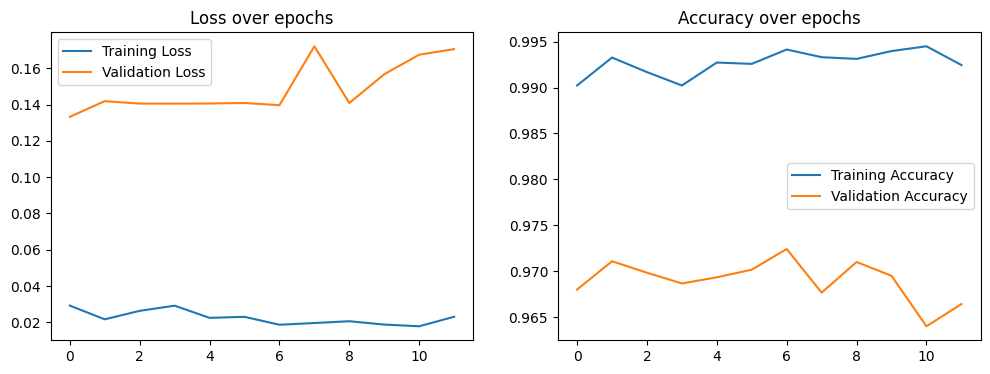

In [24]:
from tensorflow.keras.callbacks import EarlyStopping

early_stopping = EarlyStopping(
    monitor='val_accuracy', # 監控驗證準確度
    patience=5, # 若5個epoch內驗證準確度沒有提升則停止訓練
    restore_best_weights=True # 保存驗證準確度最高的模型權重
)

# 可調整超參數:batch_size, epochs, validation_split
history = model.fit(
    x_train, y_train,
    batch_size=32,
    epochs=20,
    validation_split=0.2,  # 使用20%的訓練資料作為驗證集
    callbacks=[early_stopping] # 加入早停機制避免過擬合

)

import matplotlib.pyplot as plt

# 繪製損失值變化
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Loss over epochs')

# 繪製準確度變化
plt.subplot(1, 2, 2)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Accuracy over epochs')

plt.show()

In [31]:
# 檢查早停機制實際上訓練了幾個epochs
total_epochs_run = len(history.history['loss'])
print(f"模型實際訓練了 {total_epochs_run} 個 epochs")

模型實際訓練了 12 個 epochs


# 補充：History 訓練歷史紀錄

### History 物件功能
* `history` 變數儲存訓練過程中每個 epoch 的各項指標
* 返回自 `model.fit()` 函數的結果
* 包含訓練過程中的損失值和評估指標變化
* 可用於分析模型訓練效果和診斷問題

### 資料結構說明
* `history.history` 是一個字典，包含：
  * `'loss'`: 訓練損失值列表
  * `'accuracy'`: 訓練準確度列表
  * `'val_loss'`: 驗證損失值列表
  * `'val_accuracy'`: 驗證準確度列表


### 分析診斷
* 觀察模型是否過擬合
* 判斷模型是否需要更多訓練週期
* 評估學習率是否合適
* 確認收斂情況

使用 `history` 可視化訓練過程是深度學習項目中的標準做法，有助於優化模型性能和調整超參數。

## 6. 結果檢驗

In [26]:
predict = np.argmax(model.predict(x_test), axis=-1) # 所有測試組預測出之數字(長度10000)


313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step


In [27]:
predict

array([7, 2, 1, ..., 4, 5, 6])

In [28]:
# 使用互動式檢驗模型於測試集上的預測成果
def test(測試編號):
    plt.imshow(x_test[測試編號].reshape(28,28), cmap='Greys') # 測試集輸入還原成圖片並繪製
    print('神經網路判斷為:', predict[測試編號])
interact_manual(test, 測試編號=(0, 9999));

interactive(children=(IntSlider(value=4999, description='測試編號', max=9999), Button(description='Run Interact', …

In [29]:
# 數據化顯示模型於測試集上的預測成果
score = model.evaluate(x_test, y_test)
print('模型於測試集上的預測成果:')
print('loss:', score[0])
print('正確率', score[1])

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9701 - loss: 0.1531
模型於測試集上的預測成果:
loss: 0.13189290463924408
正確率 0.9732000231742859


## 7. 模型實際使用展示 (使用Gradio)

In [32]:
def resize_image(inp):
    # 圖在 inp["layers"][0]
    image = np.array(inp["layers"][0], dtype=np.float32)
    image = image.astype(np.uint8)

    # 轉成 PIL 格式
    image_pil = Image.fromarray(image)

    # Alpha 通道設為白色, 再把圖從 RGBA 轉成 RGB
    background = Image.new("RGB", image_pil.size, (255, 255, 255))
    background.paste(image_pil, mask=image_pil.split()[3]) # 把圖片粘貼到白色背景上，使用透明通道作為遮罩
    image_pil = background

    # 轉換為灰階圖像
    image_gray = image_pil.convert("L")

    # 將灰階圖像縮放到 28x28, 轉回 numpy array
    img_array = np.array(image_gray.resize((28, 28), resample=Image.LANCZOS))

    # 配合 MNIST 數據集
    img_array = 255 - img_array

    # 拉平並縮放
    img_array = img_array.reshape(1, 784) / 255.0

    return img_array

In [33]:
def recognize_digit(inp):
    img_array = resize_image(inp)
    prediction = model.predict(img_array).flatten()
    labels = list('0123456789')
    return {labels[i]: float(prediction[i]) for i in range(10)}

In [ ]:
iface = gr.Interface(
    fn=recognize_digit,
    inputs=gr.Sketchpad(),
    outputs=gr.Label(num_top_classes=3),
    title="MNIST 手寫辨識",
    description="請在畫板上繪製數字"
)

iface.launch(share=True, debug=True)

Colab notebook detected. This cell will run indefinitely so that you can see errors and logs. To turn off, set debug=False in launch().
* Running on public URL: https://235fb075c343d022cb.gradio.live

This share link expires in 72 hours. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
